In [2]:
import struct
import pandas as pd
import pyodbc
from azure.identity import InteractiveBrowserCredential
tenant_id = "*********"

# 1. Fetch Azure Entra ID Access Token 
credential = InteractiveBrowserCredential(tenant_id=tenant_id)
token_bytes = credential.get_token(
    "https://database.windows.net/.default"
).token.encode("utf-16-le")
token_struct = struct.pack(f"<I{len(token_bytes)}s", len(token_bytes), token_bytes)

# 2. Synapse Endpoint Details
server = "sybankinganalytics-ondemand.sql.azuresynapse.net"
database = "GoldAnalytics"
driver = "{ODBC Driver 18 for SQL Server}"

conn_str = (
    f"DRIVER={driver};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Encrypt=yes;"
    f"TrustServerCertificate=yes;"
)

# 3. Connect using Access Token (SQL_COPT_SS_ACCESS_TOKEN = 1256)
SQL_COPT_SS_ACCESS_TOKEN = 1256
conn = pyodbc.connect(conn_str, attrs_before={SQL_COPT_SS_ACCESS_TOKEN: token_struct})

# 4. Query Synapse View into Pandas DataFrame
query = "SELECT * FROM dim_customer_360;"
df_cust = pd.read_sql(query, conn)

# Display Data
df_cust.head()

C:\miniconda3\Lib\site-packages\msal\oauth2cli\oauth2.py:453: UserWarning: response_mode='form_post' is recommended for better security. See https://www.rfc-editor.org/rfc/rfc9700.html#section-4.3.1
  warnings.warn(
C:\Users\QC#\AppData\Local\Temp\ipykernel_6924\3004149658.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cust = pd.read_sql(query, conn)


,user_id,national_id,nation_id_type,title,full_name,gender,nationality,email,cell_number,phone_number,...,total_volume_processed,avg_volume_amount,min_volume_amount,max_volume_amount,first_transaction_at,last_transaction_at,day_since_last_transaction,account_health_status,customer_value_tier,is_overdrawn_flag
0,003bca31-82c0-48d7-9c87-e416e9a59d03,1600562402698 21,INSEE,Mr,Alban Arnaud,male,FR,alban.arnaud@example.com,06-98-06-10-27,05-66-36-80-15,...,13314,3328.500000,2642,4742,2026-07-12,2026-08-08,1.0,Highly Active,zero_balance,False
1,00778d25-0d5f-427f-ac65-26dfb7d6f5de,None,,Mr,Adriyan Badlak,male,UA,adriyan.badlak@example.com,(096) D13-5121,(098) M84-9389,...,20054,3342.333333,2618,4795,2026-07-11,2026-08-02,7.0,Highly Active,zero_balance,False
2,00d05fbe-f4b9-4417-bee9-edefc897ce55,141206656,SIN,Mr,Aiden Andersen,male,CA,aiden.andersen@example.com,J89 V61-3876,U55 L79-3394,...,26203,2382.090909,1175,4425,2026-07-10,2026-08-04,5.0,Highly Active,zero_balance,False
3,01192e0f-d45a-432f-b6d9-aecbb9575c80,None,,Miss,????? ?????,female,IR,anyt.hsyny@example.com,0967-717-4603,053-43750154,...,16495,2061.875000,249,4516,2026-07-11,2026-08-02,7.0,Highly Active,zero_balance,False
4,01a12221-4da9-45e0-8639-a401fdf5a8ef,179821806,SID,Ms,Andrea Brankovic,female,RS,andrea.brankovic@example.com,065-8428-918,039-3658-948,...,6231,2077.000000,337,4718,2026-07-10,2026-08-06,3.0,Highly Active,zero_balance,False


In [3]:
query= "select * from fct_banking_transactions"
df_fct_tran= pd.read_sql(query, conn)
df_fct_tran

C:\Users\QC#\AppData\Local\Temp\ipykernel_6924\1718244746.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_fct_tran= pd.read_sql(query, conn)


,transaction_id,user_id,transaction_type,amount,transaction_category,transaction_timestamp,customer_name,customer_email,customer_country,customer_city,customer_gender,customer_age
0,TXN_1001,5e62b572-4551-4a0d-a3d0-24a7c08ce816,withdrawal,4733,Medium Value,2026-07-17,Evelyn Thompson,evelyn.thompson@example.com,Australia,Kalgoorlie,female,44
1,TXN_1002,b671054e-d971-4da4-bbe5-fe3711690bbf,withdrawal,4821,Medium Value,2026-08-04,Noah Khalil,noah.khalil@example.com,Norway,Høyanger,male,30
2,TXN_1003,6a2f4977-8c24-41de-b83e-ac9b5b40546f,deposit,4965,Medium Value,2026-07-27,Johan Owren,johan.owren@example.com,Norway,Norheimsund,male,37
3,TXN_1004,b2d736a8-376d-4ece-8fe4-f5bd62bc1294,transfer,406,Low Value,2026-08-02,Oskari Honkala,oskari.honkala@example.com,Finland,Lapua,male,63
4,TXN_1005,b2d736a8-376d-4ece-8fe4-f5bd62bc1294,payment,31,Low Value,2026-08-09,Oskari Honkala,oskari.honkala@example.com,Finland,Lapua,male,63
...,...,...,...,...,...,...,...,...,...,...,...,...
4994,TXN_5995,ff351404-d892-444a-a31f-42b57b50aaef,withdrawal,1579,Medium Value,2026-07-21,Yolanda Vázquez,yolanda.vazquez@example.com,Spain,Alcalá de Henares,female,42
4995,TXN_5996,7a2135cc-c893-457b-b3d4-96a5932dc447,deposit,4760,Medium Value,2026-08-03,Kian Rahimi,kian.rahimi@example.com,Norway,Kirkebygden,male,57
4996,TXN_5997,71c0590e-81f7-4212-8580-5bf7be82ba57,withdrawal,4172,Medium Value,2026-07-15,Linnea Harju,linnea.harju@example.com,Finland,Alavus,female,28
4997,TXN_5998,02487823-9b4c-46b8-921b-c0f405b11e91,withdrawal,479,Low Value,2026-08-03,Ansgar Dobler,ansgar.dobler@example.com,Germany,Mayen-Koblenz,male,80


In [4]:
df_cust.isna().sum()

user_id                         0
national_id                   155
nation_id_type                  0
title                           0
full_name                       0
gender                          0
nationality                     0
email                           0
cell_number                     0
phone_number                    0
street_name                     0
street_number                   0
city                            0
user_state                      0
country                         0
postal_code                     0
coordinate_latitude             0
coordinate_longitude            0
timezone_description            0
timezone_offset                 0
date_of_birth                   0
age                             0
registration_date               0
account_age_year                0
username                        0
password                        0
password_salt                   0
md5_hash                        0
profile_pic_large               0
profile_pic_me

In [5]:
df_fct_tran.isnull().sum()

transaction_id           0
user_id                  0
transaction_type         0
amount                   0
transaction_category     0
transaction_timestamp    0
customer_name            0
customer_email           0
customer_country         0
customer_city            0
customer_gender          0
customer_age             0
dtype: int64

In [6]:
df_cust

,user_id,national_id,nation_id_type,title,full_name,gender,nationality,email,cell_number,phone_number,...,total_volume_processed,avg_volume_amount,min_volume_amount,max_volume_amount,first_transaction_at,last_transaction_at,day_since_last_transaction,account_health_status,customer_value_tier,is_overdrawn_flag
0,003bca31-82c0-48d7-9c87-e416e9a59d03,1600562402698 21,INSEE,Mr,Alban Arnaud,male,FR,alban.arnaud@example.com,06-98-06-10-27,05-66-36-80-15,...,13314,3328.500000,2642,4742,2026-07-12,2026-08-08,1.0,Highly Active,zero_balance,False
1,00778d25-0d5f-427f-ac65-26dfb7d6f5de,None,,Mr,Adriyan Badlak,male,UA,adriyan.badlak@example.com,(096) D13-5121,(098) M84-9389,...,20054,3342.333333,2618,4795,2026-07-11,2026-08-02,7.0,Highly Active,zero_balance,False
2,00d05fbe-f4b9-4417-bee9-edefc897ce55,141206656,SIN,Mr,Aiden Andersen,male,CA,aiden.andersen@example.com,J89 V61-3876,U55 L79-3394,...,26203,2382.090909,1175,4425,2026-07-10,2026-08-04,5.0,Highly Active,zero_balance,False
3,01192e0f-d45a-432f-b6d9-aecbb9575c80,None,,Miss,????? ?????,female,IR,anyt.hsyny@example.com,0967-717-4603,053-43750154,...,16495,2061.875000,249,4516,2026-07-11,2026-08-02,7.0,Highly Active,zero_balance,False
4,01a12221-4da9-45e0-8639-a401fdf5a8ef,179821806,SID,Ms,Andrea Brankovic,female,RS,andrea.brankovic@example.com,065-8428-918,039-3658-948,...,6231,2077.000000,337,4718,2026-07-10,2026-08-06,3.0,Highly Active,zero_balance,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,fe9d95b8-1a92-4634-a7dc-fb249b7c6e97,GT 00 11 37 W,NINO,Mrs,Tracy Thompson,female,GB,tracy.thompson@example.com,07466 718332,016973 90617,...,13755,2751.000000,1582,4964,2026-07-11,2026-08-09,0.0,Highly Active,zero_balance,False
886,fea254d0-d3ce-409f-a330-46c6fa932ea9,340448403,TFN,Mr,Warren Wallace,male,AU,warren.wallace@example.com,0474-080-856,09-6521-8662,...,18713,3118.833333,681,4811,2026-07-10,2026-08-05,4.0,Highly Active,zero_balance,False
887,fed150f3-6d77-4bd6-ae31-d9bfff538f14,151177-7971,CPR,Mr,William Sørensen,male,DK,william.sorensen@example.com,99485178,99325912,...,13618,1702.250000,443,4145,2026-07-11,2026-08-02,7.0,Highly Active,zero_balance,False
888,ff351404-d892-444a-a31f-42b57b50aaef,46091073-G,DNI,Miss,Yolanda Vázquez,female,ES,yolanda.vazquez@example.com,698-582-309,973-066-999,...,21322,1938.363636,203,3844,2026-07-10,2026-08-08,1.0,Highly Active,zero_balance,False


In [7]:
df=pd.merge(df_fct_tran, df_cust, on='user_id', how='inner')

In [8]:
df

,transaction_id,user_id,transaction_type,amount,transaction_category,transaction_timestamp,customer_name,customer_email,customer_country,customer_city,...,total_volume_processed,avg_volume_amount,min_volume_amount,max_volume_amount,first_transaction_at,last_transaction_at,day_since_last_transaction,account_health_status,customer_value_tier,is_overdrawn_flag
0,TXN_1001,5e62b572-4551-4a0d-a3d0-24a7c08ce816,withdrawal,4733,Medium Value,2026-07-17,Evelyn Thompson,evelyn.thompson@example.com,Australia,Kalgoorlie,...,15270,3054.000000,306,4733,2026-07-17,2026-08-09,0.0,Highly Active,zero_balance,False
1,TXN_1002,b671054e-d971-4da4-bbe5-fe3711690bbf,withdrawal,4821,Medium Value,2026-08-04,Noah Khalil,noah.khalil@example.com,Norway,Høyanger,...,23037,2559.666667,170,4821,2026-07-13,2026-08-08,1.0,Highly Active,zero_balance,False
2,TXN_1003,6a2f4977-8c24-41de-b83e-ac9b5b40546f,deposit,4965,Medium Value,2026-07-27,Johan Owren,johan.owren@example.com,Norway,Norheimsund,...,9258,3086.000000,1308,4965,2026-07-12,2026-07-27,13.0,Highly Active,zero_balance,False
3,TXN_1004,b2d736a8-376d-4ece-8fe4-f5bd62bc1294,transfer,406,Low Value,2026-08-02,Oskari Honkala,oskari.honkala@example.com,Finland,Lapua,...,12215,1221.500000,31,3527,2026-07-13,2026-08-09,0.0,Highly Active,zero_balance,False
4,TXN_1005,b2d736a8-376d-4ece-8fe4-f5bd62bc1294,payment,31,Low Value,2026-08-09,Oskari Honkala,oskari.honkala@example.com,Finland,Lapua,...,12215,1221.500000,31,3527,2026-07-13,2026-08-09,0.0,Highly Active,zero_balance,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,TXN_5995,ff351404-d892-444a-a31f-42b57b50aaef,withdrawal,1579,Medium Value,2026-07-21,Yolanda Vázquez,yolanda.vazquez@example.com,Spain,Alcalá de Henares,...,21322,1938.363636,203,3844,2026-07-10,2026-08-08,1.0,Highly Active,zero_balance,False
4995,TXN_5996,7a2135cc-c893-457b-b3d4-96a5932dc447,deposit,4760,Medium Value,2026-08-03,Kian Rahimi,kian.rahimi@example.com,Norway,Kirkebygden,...,30385,2762.272727,147,4760,2026-07-10,2026-08-03,6.0,Highly Active,zero_balance,False
4996,TXN_5997,71c0590e-81f7-4212-8580-5bf7be82ba57,withdrawal,4172,Medium Value,2026-07-15,Linnea Harju,linnea.harju@example.com,Finland,Alavus,...,17270,2878.333333,1253,4364,2026-07-10,2026-07-31,9.0,Highly Active,zero_balance,False
4997,TXN_5998,02487823-9b4c-46b8-921b-c0f405b11e91,withdrawal,479,Low Value,2026-08-03,Ansgar Dobler,ansgar.dobler@example.com,Germany,Mayen-Koblenz,...,26938,2244.833333,166,4499,2026-07-17,2026-08-08,1.0,Highly Active,zero_balance,False


In [9]:
df.isna().sum()

transaction_id                  0
user_id                         0
transaction_type                0
amount                          0
transaction_category            0
transaction_timestamp           0
customer_name                   0
customer_email                  0
customer_country                0
customer_city                   0
customer_gender                 0
customer_age                    0
national_id                   893
nation_id_type                  0
title                           0
full_name                       0
gender                          0
nationality                     0
email                           0
cell_number                     0
phone_number                    0
street_name                     0
street_number                   0
city                            0
user_state                      0
country                         0
postal_code                     0
coordinate_latitude             0
coordinate_longitude            0
timezone_descr

In [10]:
df.columns

Index(['transaction_id', 'user_id', 'transaction_type', 'amount',
       'transaction_category', 'transaction_timestamp', 'customer_name',
       'customer_email', 'customer_country', 'customer_city',
       'customer_gender', 'customer_age', 'national_id', 'nation_id_type',
       'title', 'full_name', 'gender', 'nationality', 'email', 'cell_number',
       'phone_number', 'street_name', 'street_number', 'city', 'user_state',
       'country', 'postal_code', 'coordinate_latitude', 'coordinate_longitude',
       'timezone_description', 'timezone_offset', 'date_of_birth', 'age',
       'registration_date', 'account_age_year', 'username', 'password',
       'password_salt', 'md5_hash', 'profile_pic_large', 'profile_pic_medium',
       'profile_pic_thumbnail', 'total_transaction_count',
       'total_deposit_amount', 'total_withdrawal_amount',
       'estimated_net_balance', 'total_volume_processed', 'avg_volume_amount',
       'min_volume_amount', 'max_volume_amount', 'first_transaction_

In [11]:
df.describe().reset_index()

,index,amount,customer_age,age,account_age_year,total_transaction_count,total_deposit_amount,total_withdrawal_amount,estimated_net_balance,total_volume_processed,avg_volume_amount,min_volume_amount,max_volume_amount,day_since_last_transaction
0,count,4999.000000,4999.000000,4999.000000,4999.00000,4999.000000,4999.0,4999.0,4999.0,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000
1,mean,2518.588118,53.033207,53.033207,13.75095,6.593519,0.0,0.0,0.0,16570.144629,2518.588118,730.936387,4292.507902,4.137027
2,std,1450.197544,16.875142,16.875142,5.64703,2.335506,0.0,0.0,0.0,6818.178944,596.912485,702.656115,674.185358,4.337298
3,min,12.000000,25.000000,25.000000,4.00000,1.000000,0.0,0.0,0.0,491.000000,463.000000,12.000000,489.000000,0.000000
4,25%,1248.000000,39.000000,39.000000,9.00000,5.000000,0.0,0.0,0.0,11614.000000,2137.571429,224.000000,4030.000000,1.000000
5,50%,2527.000000,52.000000,52.000000,14.00000,6.000000,0.0,0.0,0.0,15991.000000,2520.666667,476.000000,4497.000000,3.000000
6,75%,3764.500000,68.000000,68.000000,18.00000,8.000000,0.0,0.0,0.0,20916.000000,2891.166667,1049.000000,4774.000000,6.000000
7,max,4999.000000,81.000000,81.000000,24.00000,15.000000,0.0,0.0,0.0,39035.000000,4745.000000,4745.000000,4999.000000,30.000000


In [12]:
(df[['total_deposit_amount','total_withdrawal_amount', 	'estimated_net_balance']]>0).sum()

total_deposit_amount       0
total_withdrawal_amount    0
estimated_net_balance      0
dtype: int64

In [13]:
# Calculate actual deposits and withdrawals using case-insensitive check
deposit_mask = df_fct_tran['transaction_type'].str.lower() == 'deposit'
withdrawal_mask = df_fct_tran['transaction_type'].str.lower() == 'withdrawal'

deposits = df_fct_tran[deposit_mask].groupby('user_id')['amount'].sum()
withdrawals = df_fct_tran[withdrawal_mask].groupby('user_id')['amount'].sum()

df['total_deposit_amount'] = df['user_id'].map(deposits).fillna(0)
df['total_withdrawal_amount'] = df['user_id'].map(withdrawals).fillna(0)
df['estimated_net_balance'] = df['total_deposit_amount'] - df['total_withdrawal_amount']

print(df[['total_deposit_amount', 'total_withdrawal_amount', 'estimated_net_balance']].sum())
deposit_mask = df_fct_tran['transaction_type'].str.lower() == 'deposit'
withdrawal_mask = df_fct_tran['transaction_type'].str.lower() == 'withdrawal'

deposits = df_fct_tran[deposit_mask].groupby('user_id')['amount'].sum()
withdrawals = df_fct_tran[withdrawal_mask].groupby('user_id')['amount'].sum()

df['total_deposit_amount'] = df['user_id'].map(deposits).fillna(0)
df['total_withdrawal_amount'] = df['user_id'].map(withdrawals).fillna(0)
df['estimated_net_balance'] = df['total_deposit_amount'] - df['total_withdrawal_amount']

print(df[['total_deposit_amount', 'total_withdrawal_amount', 'estimated_net_balance']].sum())

total_deposit_amount       20743376.0
total_withdrawal_amount    20551204.0
estimated_net_balance        192172.0
dtype: float64
total_deposit_amount       20743376.0
total_withdrawal_amount    20551204.0
estimated_net_balance        192172.0
dtype: float64


In [14]:
df.describe()

,amount,customer_age,age,account_age_year,total_transaction_count,total_deposit_amount,total_withdrawal_amount,estimated_net_balance,total_volume_processed,avg_volume_amount,min_volume_amount,max_volume_amount,day_since_last_transaction
count,4999.000000,4999.000000,4999.000000,4999.00000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000
mean,2518.588118,53.033207,53.033207,13.75095,6.593519,4149.505101,4111.063013,38.442088,16570.144629,2518.588118,730.936387,4292.507902,4.137027
std,1450.197544,16.875142,16.875142,5.64703,2.335506,3521.360717,3747.561082,5350.394116,6818.178944,596.912485,702.656115,674.185358,4.337298
min,12.000000,25.000000,25.000000,4.00000,1.000000,0.000000,0.000000,-16714.000000,491.000000,463.000000,12.000000,489.000000,0.000000
25%,1248.000000,39.000000,39.000000,9.00000,5.000000,1031.000000,800.000000,-3310.000000,11614.000000,2137.571429,224.000000,4030.000000,1.000000
50%,2527.000000,52.000000,52.000000,14.00000,6.000000,3668.000000,3557.000000,170.000000,15991.000000,2520.666667,476.000000,4497.000000,3.000000
75%,3764.500000,68.000000,68.000000,18.00000,8.000000,6319.000000,6054.000000,3624.000000,20916.000000,2891.166667,1049.000000,4774.000000,6.000000
max,4999.000000,81.000000,81.000000,24.00000,15.000000,21230.000000,21363.000000,21230.000000,39035.000000,4745.000000,4745.000000,4999.000000,30.000000


In [21]:
# Country summary with Net Cash Flow 
country_summary = df.groupby('country').agg({
    'total_deposit_amount': 'sum',
    'total_withdrawal_amount': 'sum',
    'estimated_net_balance': 'sum'
}).reset_index().sort_values(by='estimated_net_balance', ascending=False)
display(country_summary)

,country,total_deposit_amount,total_withdrawal_amount,estimated_net_balance
3,Denmark,1096911.0,867620.0,229291.0
20,United States,1273292.0,1048291.0,225001.0
19,United Kingdom,1224823.0,1001830.0,222993.0
5,France,995776.0,776622.0,219154.0
16,Switzerland,1285443.0,1074274.0,211169.0
18,Ukraine,880323.0,697635.0,182688.0
10,Mexico,620570.0,439438.0,181132.0
1,Brazil,1064106.0,898440.0,165666.0
11,Netherlands,918856.0,801316.0,117540.0
13,Norway,1090282.0,1033577.0,56705.0


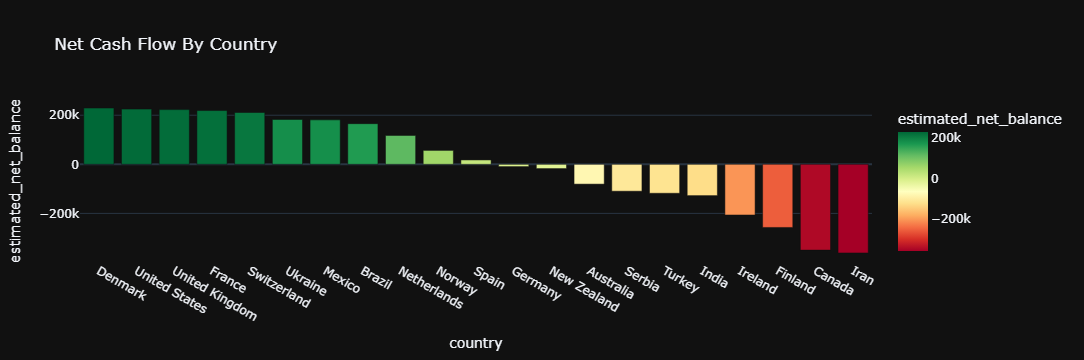

In [22]:
fig_net_flow=px.bar(
    country_summary,
    x='country',
    y='estimated_net_balance',
    title='Net Cash Flow By Country',
    color='estimated_net_balance',
    color_continuous_scale='RdYlGn',
    template='plotly_dark'
)
fig_net_flow.show()

### Key Insights: Net Cash Flow by Country

1. Liquidity Generation Leaders: **Denmark**, **United States**, and **United Kingdom** generate the highest positive net liquidity 
(~+200k), indicating high capital retention and low churn risk in these regions.
2. Capital Outflow Risks: **Iran**, **Canada**, and **Finland** face severe negative net cash flows
(~-200k), where customer withdrawals significantly outpace incoming deposits.
3. Strategic Recommendation: Scale high-yield savings and investment products in top-tier markets (Denmark/US).
Implement liquidity retention campaigns and targeted transfer perks in high-outflow regions to reduce capital flight.


In [30]:
risk_summary= df.groupby(['country', 'account_health_status'])['user_id'].count().reset_index()
display(risk_summary)                  

,country,account_health_status,user_id
0,Australia,Highly Active,286
1,Brazil,Highly Active,254
2,Canada,Highly Active,192
3,Denmark,Highly Active,251
4,Finland,Highly Active,244
5,France,Highly Active,236
6,Germany,Highly Active,259
7,India,Highly Active,266
8,Iran,Highly Active,220
9,Ireland,Highly Active,286


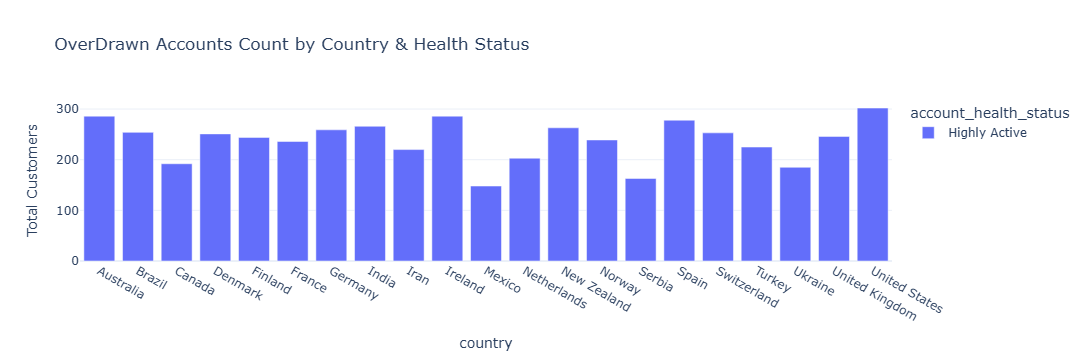

In [32]:
flag_risk = px.bar(
    risk_summary,
    x='country',
    y='user_id',
    color='account_health_status',
    title= 'OverDrawn Accounts Count by Country & Health Status',
    barmode= 'group',
    labels={'user_id': 'Total Customers'},
    template='plotly_white'
)
flag_risk.show()

 ### Key Insights: Customer Distribution by Country

1. Core User Base: The **United States**, **Spain**, and **Ireland** lead in total active account volume, maintaining over 300 active users each.
2. Underrepresented Markets: **Mexico** shows the lowest overall user adoption (~180 customers), despite showing moderate transactional volume.
3. Strategic Recommendation: Focus marketing and customer acquisition budgets on high-conversion markets like the US and UK, while launching localized
onboarding initiatives in low-volume regions like Mexico to boost user penetration.


C:\Users\QC#\AppData\Local\Temp\ipykernel_6924\2681353112.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = df.groupby('age_group')['total_volume_processed'].mean().reset_index()


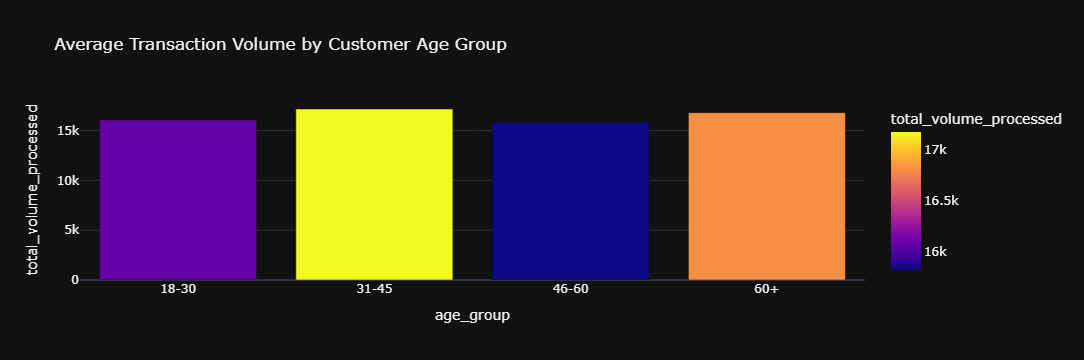

In [33]:
bins = [17, 30, 45, 60, 100]
labels = ['18-30', '31-45', '46-60', '60+']
df['age_group'] = pd.cut(df['customer_age'], bins=bins, labels=labels)

age_summary = df.groupby('age_group')['total_volume_processed'].mean().reset_index()

fig_age = px.bar(
    age_summary,
    x='age_group',
    y='total_volume_processed',
    title='Average Transaction Volume by Customer Age Group',
    color='total_volume_processed',
    template='plotly_dark'
)
fig_age.show()

### Key Insights: Volume Distribution by Customer Age

* **Primary Revenue Drivers**: Customers aged **31–45** account for the highest average transaction volume (~$17.5k per user), representing the core working demographic.
* **Consistent Mature Segment**: The **60+ age group** maintains strong, steady transaction volume (~$16.5k), demonstrating high long-term value and stability.
* **Strategic Recommendation**: Design tailored financial products—such as premium credit tiers for the **31–45** cohort and simplified, secure wealth-preservation services for the **60+** demographic—to maximize customer lifetime value (CLV).
*

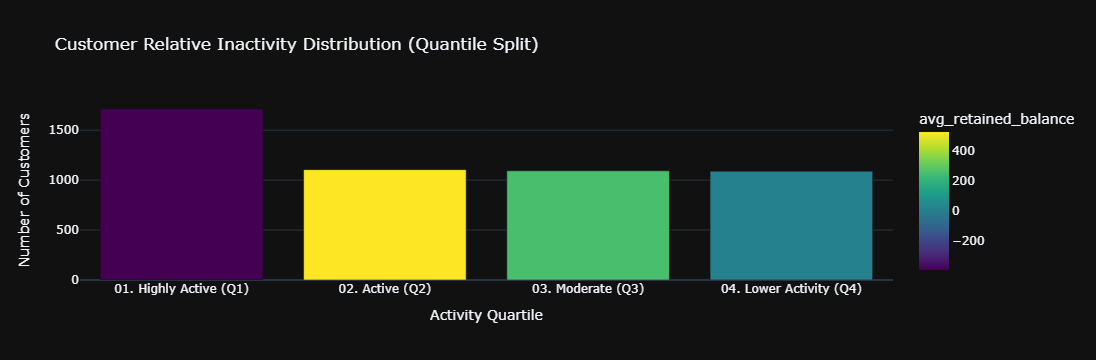

In [39]:
# 1. Quantile-based binning 
df['inactivity_bracket'] = pd.qcut(
    df['day_since_last_transaction'], 
    q=4, 
    labels=['01. Highly Active (Q1)', '02. Active (Q2)', '03. Moderate (Q3)', '04. Lower Activity (Q4)']
)

# 2. Aggregation
inactivity_summary = df.groupby('inactivity_bracket', observed=False).agg(
    total_customers=('user_id', 'count'),
    avg_retained_balance=('estimated_net_balance', 'mean')
).reset_index()

# 3. Bar Chart
fig_inactivity = px.bar(
    inactivity_summary,
    x='inactivity_bracket',
    y='total_customers',
    color='avg_retained_balance',
    title='Customer Relative Inactivity Distribution (Quantile Split)',
    labels={'inactivity_bracket': 'Activity Quartile', 'total_customers': 'Number of Customers'},
    color_continuous_scale='Viridis',
    template='plotly_dark'
)

fig_inactivity.show()

### 💡 Key Insights: Relative Inactivity & Retained Balance

* **Activity vs. Liquidity Paradox**: **Highly Active (Q1)** users make up the largest chunk of customers (>1,500), but **Active (Q2)** customers hold the highest average retained balance.
* **Capital Retention Dynamics**: Q1 users have high transaction frequency, but their retained balance shows net outflow. In contrast, Q2 users consistently park capital on the platform.
* **Strategic Recommendation**: Target the Q2 cohort with VIP retention incentives to maintain core liquidity, and introduce automated high-yield savings products for Q1 users to encourage capital retention over frequent withdrawals.

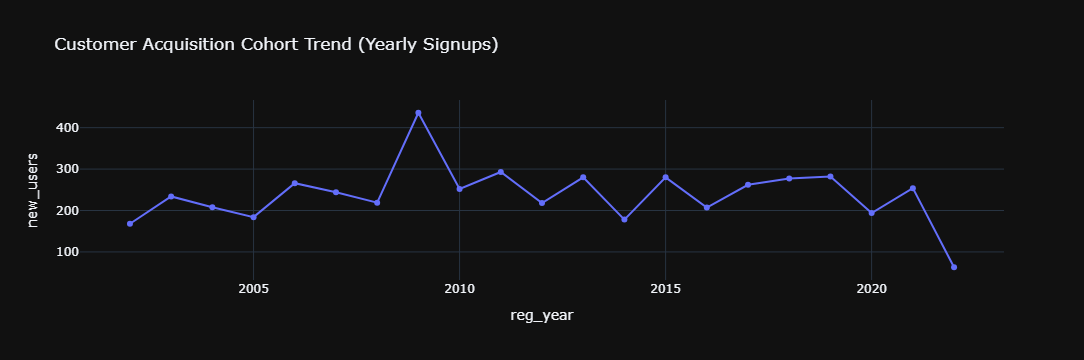

In [40]:
# Convert registration date to datetime year
df['reg_year'] = pd.to_datetime(df['registration_date']).dt.year

cohort_summary = df.groupby('reg_year').agg(
    new_users=('user_id', 'count'),
    avg_volume=('total_volume_processed', 'mean')
).reset_index()

fig_cohort = px.line(
    cohort_summary,
    x='reg_year',
    y='new_users',
    markers=True,
    title='Customer Acquisition Cohort Trend (Yearly Signups)',
    template='plotly_dark'
)
fig_cohort.show()

### Key Insights: Yearly Acquisition Cohort Dynamics

* **Peak Growth Era**: Customer onboarding hit an all-time peak around **2009–2010** with over 400+ new signups in a single year.
* **Steady Baseline**: From 2011 to 2022, account registration remained stable (200–300 new users per year), followed by a sharp drop in the most recent acquisition cycle.
* **Strategic Recommendation**: Audit the onboarding funnel and marketing spend to identify root causes of the recent acquisition decline, and reactivate high-conversion acquisition channels used during the 2009–2010 growth phase.